In [80]:
import pandas as pd
import numpy as np
df = pd.read_csv("Ames Housing/AmesHousing-Cleaned.csv", keep_default_na=False, na_values=[''])

In [81]:
df.isnull().sum().sort_values(ascending=False)

Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
Total SF          0
Length: 83, dtype: int64

In [82]:
# 1. Create Total Square Footage
# This is usually the strongest predictor of house price
df['Total SF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']

In [83]:
# 3. Create Total Bathrooms
# Full bath = 1, Half bath = 0.5
df['Total Bathrooms'] = (df['Full Bath'] + (0.5 * df['Half Bath']) + 
                         df['Bsmt Full Bath'] + (0.5 * df['Bsmt Half Bath']))

In [84]:
# 4. Create House Age
# Newer houses are usually more expensive
df['House Age'] = df['Yr Sold'] - df['Year Built']
df['Years Since Remodel'] = df['Yr Sold'].astype(int) - df['Year Remod/Add']

In [85]:
# 4. Binary Features (Flag features)
# Does the house have a pool? (1 if yes, 0 if no)
df['Has Pool'] = df['Pool Area'].apply(lambda x: 1 if x > 0 else 0)

In [86]:

# 5. Log Transformation of SalePrice
# We use log1p (log of 1 + x) for mathematical stability
df['SalePrice'] = np.log1p(df['SalePrice'])
print("New Features created. Current Shape:", df.shape)

New Features created. Current Shape: (2927, 87)


In [87]:
# --- Remove original columns used for engineering ---
# We have already extracted their value into 'Total SF', 'Total Bathrooms', and 'House Age'
cols_to_drop = [
    'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 
    'Full Bath', 'Half Bath', 'Bsmt Full Bath', 'Bsmt Half Bath',
    'Year Built', 'Year Remod/Add'
]

# Drop the columns
df = df.drop(cols_to_drop, axis=1)

print(f"Successfully dropped {len(cols_to_drop)} original columns.")
print("Remaining columns:", len(df.columns))


Successfully dropped 9 original columns.
Remaining columns: 78


In [88]:
# --- Ordinal Encoding (Quality & Condition) ---
# 1. Define the standard rating map
# We map 'None' to 0 because we already cleaned the NaNs to 'None'
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

In [89]:
# 2. List of all columns that use this standard rating scale
qual_cols = [
    'Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 
    'Heating QC', 'Kitchen Qual', 'Fireplace Qu', 
    'Garage Qual', 'Garage Cond', 'Pool QC'
]

In [90]:
# 3. Apply the mapping
for col in qual_cols:
    df[col] = df[col].map(qual_map)


In [91]:
# 4. Handle 'Bsmt Exposure' separately (it has its own diff labels)
exposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
df['Bsmt Exposure'] = df['Bsmt Exposure'].map(exposure_map)


In [92]:
# 5. Handle 'BsmtFin Type 1' and 'Type 2'
bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
df['BsmtFin Type 1'] = df['BsmtFin Type 1'].map(bsmt_fin_map)
df['BsmtFin Type 2'] = df['BsmtFin Type 2'].map(bsmt_fin_map)

In [93]:
# --- One-Hot Encoding (Remaining Nominal Categories) ---
final_cat_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=final_cat_cols, drop_first=True)
print(f"Final Shape of your dataset: {df.shape}")

Final Shape of your dataset: (2927, 225)


In [94]:
df.value_counts()

Order  PID        MS SubClass  Lot Frontage  Lot Area  Overall Qual  Overall Cond  Mas Vnr Area  Exter Qual  Exter Cond  Bsmt Qual  Bsmt Cond  Bsmt Exposure  BsmtFin Type 1  BsmtFin SF 1  BsmtFin Type 2  BsmtFin SF 2  Bsmt Unf SF  Heating QC  Low Qual Fin SF  Gr Liv Area  Bedroom AbvGr  Kitchen AbvGr  Kitchen Qual  TotRms AbvGrd  Fireplaces  Fireplace Qu  Garage Yr Blt  Garage Cars  Garage Area  Garage Qual  Garage Cond  Wood Deck SF  Open Porch SF  Enclosed Porch  3Ssn Porch  Screen Porch  Pool Area  Pool QC  Misc Val  Mo Sold  Yr Sold  SalePrice  Total SF  Total Bathrooms  House Age  Years Since Remodel  Has Pool  MS Zoning_C (all)  MS Zoning_FV  MS Zoning_I (all)  MS Zoning_RH  MS Zoning_RL  MS Zoning_RM  Street_Pave  Alley_None  Alley_Pave  Lot Shape_IR2  Lot Shape_IR3  Lot Shape_Reg  Land Contour_HLS  Land Contour_Low  Land Contour_Lvl  Utilities_NoSeWa  Utilities_NoSewr  Lot Config_CulDSac  Lot Config_FR2  Lot Config_FR3  Lot Config_Inside  Land Slope_Mod  Land Slope_Sev  Neighbo

In [95]:
df.isnull().sum().sort_values(ascending=False)

Order                     0
PID                       0
MS SubClass               0
Lot Frontage              0
Lot Area                  0
                         ..
Sale Condition_AdjLand    0
Sale Condition_Alloca     0
Sale Condition_Family     0
Sale Condition_Normal     0
Sale Condition_Partial    0
Length: 225, dtype: int64

In [96]:
df.to_csv("Ames Housing/AmesHousing-featured.csv", index=False)

--- Top 15 Most Influential Features ---
SalePrice           1.000000
Overall Qual        0.828533
Total SF            0.819773
Gr Liv Area         0.714439
Exter Qual          0.687158
Bsmt Qual           0.686136
Garage Cars         0.675240
Kitchen Qual        0.668335
Total Bathrooms     0.668240
Garage Area         0.654181
Pool QC             0.633485
Garage Yr Blt       0.597113
Foundation_PConc    0.544492
TotRms AbvGrd       0.496285
Heating QC          0.493001
Fireplaces          0.490413
Name: SalePrice, dtype: float64

--- Features that Lower House Value ---
MS Zoning_RM          -0.349053
Garage Type_Detchd    -0.397461
Garage Finish_Unf     -0.437971
Years Since Remodel   -0.588545
House Age             -0.616297
Name: SalePrice, dtype: float64


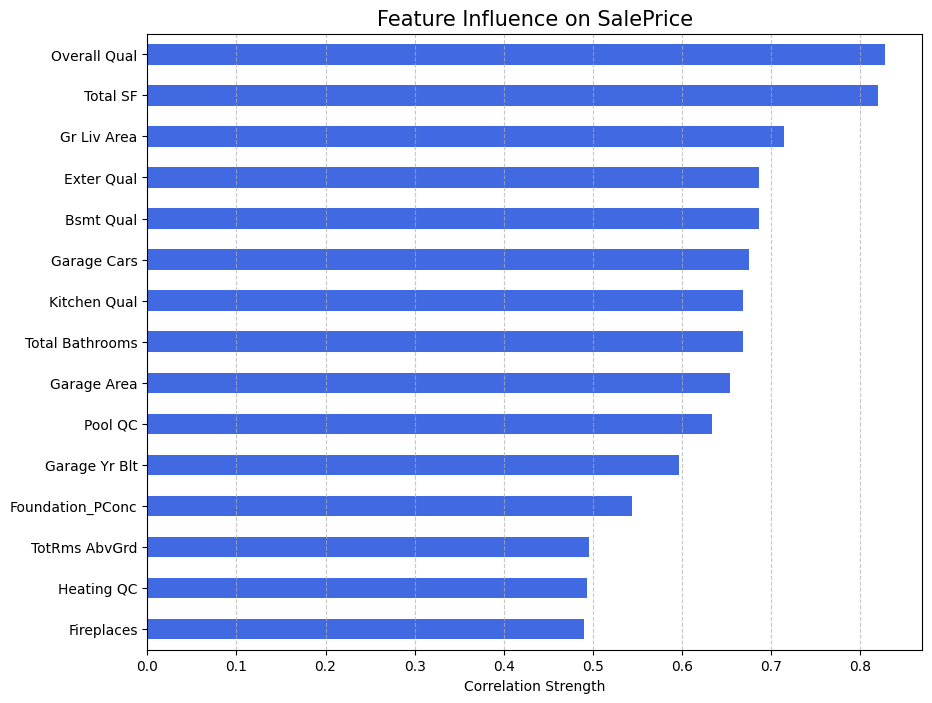

In [52]:
# --- Correlation Validation ---

# 1. Calculate correlation of all numeric features with SalePrice
# Since we log-transformed SalePrice, these relationships will be very clear
correlations = df.corr()['SalePrice'].sort_values(ascending=False)

# 2. Display the top 15 positive correlations
print("--- Top 15 Most Influential Features ---")
print(correlations.head(16)) # Including SalePrice itself

# 3. Display the top 5 negative correlations (things that lower value)
print("\n--- Features that Lower House Value ---")
print(correlations.tail(5))

# 4. Visualize the Top 15
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
correlations.drop('SalePrice').head(15).plot(kind='barh', color='royalblue')
plt.title('Feature Influence on SalePrice', fontsize=15)
plt.xlabel('Correlation Strength')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [53]:
# --- Creating an Interaction Feature ---

# Multiply Quality by Total Square Footage
# Note: Since Overall Qual is now a string (if you did the type correction), 
# we cast it back to int for the math.
df['Qual_x_SF'] = df['Overall Qual'].astype(int) * df['Total SF']

# Let's check its correlation vs the individual features
print(f"Correlation - Overall Qual: {df['Overall Qual'].astype(int).corr(df['SalePrice']):.4f}")
print(f"Correlation - Total SF:    {df['Total SF'].corr(df['SalePrice']):.4f}")
print(f"Correlation - INTERACTION: {df['Qual_x_SF'].corr(df['SalePrice']):.4f}")

df = df.drop(['Overall Qual', 'Total SF'], axis=1)


Correlation - Overall Qual: 0.8285
Correlation - Total SF:    0.8198
Correlation - INTERACTION: 0.8841
